In [1]:
import pandas as pd
import random
from datetime import datetime, timedelta

# Sample data
products = ['Laptop','Headphones','Mouse','Keyboard','Monitor','Webcam','Chair','Desk','Printer','Tablet']
categories = ['Electronics','Accessories','Furniture','Peripherals']
regions = ['North','South','East','West']

data = []
start_date = datetime.now() - timedelta(days=365)

for i in range(1, 201):
    product = random.choice(products)
    category = random.choice(categories)
    quantity = random.randint(1,5)
    price = round(random.uniform(20, 1000), 2)
    revenue = quantity * price
    date = start_date + timedelta(days=random.randint(0,365))
    region = random.choice(regions)
    data.append([i, date, product, category, quantity, price, revenue, region])

df = pd.DataFrame(data, columns=['OrderID','Date','Product','Category','Quantity','Price','Revenue','Region'])
df.to_csv('sales_data.csv', index=False)
df.head()

,OrderID,Date,Product,Category,Quantity,Price,Revenue,Region
0,1,2025-04-09 08:42:52.736515,Tablet,Peripherals,3,286.20,858.60,West
1,2,2025-12-18 08:42:52.736515,Monitor,Furniture,5,869.11,4345.55,West
2,3,2026-02-06 08:42:52.736515,Laptop,Accessories,4,867.38,3469.52,West
3,4,2025-10-22 08:42:52.736515,Chair,Electronics,5,857.58,4287.90,North
4,5,2026-02-01 08:42:52.736515,Monitor,Furniture,1,295.50,295.50,East


In [4]:
df.to_csv('sales_data.csv', index=False)


In [2]:
df = pd.read_csv('sales_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   OrderID   200 non-null    int64         
 1   Date      200 non-null    datetime64[ns]
 2   Product   200 non-null    object        
 3   Category  200 non-null    object        
 4   Quantity  200 non-null    int64         
 5   Price     200 non-null    float64       
 6   Revenue   200 non-null    float64       
 7   Region    200 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(3)
memory usage: 12.6+ KB
None


,OrderID,Date,Product,Category,Quantity,Price,Revenue,Region
0,1,2025-07-01 21:44:05.888218,Desk,Electronics,1,116.89,116.89,South
1,2,2025-10-21 21:44:05.888218,Chair,Peripherals,2,166.98,333.96,West
2,3,2025-10-04 21:44:05.888218,Desk,Peripherals,1,548.10,548.10,South
3,4,2025-11-17 21:44:05.888218,Chair,Furniture,5,575.25,2876.25,West
4,5,2025-12-30 21:44:05.888218,Tablet,Accessories,1,959.07,959.07,East


In [3]:

df = df.drop_duplicates()

# Fill missing values
df['Quantity'] = df['Quantity'].fillna(0)
df['Revenue'] = df['Revenue'].fillna(0)

df.isnull().sum()

OrderID     0
Date        0
Product     0
Category    0
Quantity    0
Price       0
Revenue     0
Region      0
dtype: int64

In [4]:
total_revenue = df['Revenue'].sum()
total_quantity = df['Quantity'].sum()
avg_order = df['Revenue'].mean()

print(f"Total Revenue: ${total_revenue:.2f}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Order Value: ${avg_order:.2f}")

Total Revenue: $290002.84
Total Quantity Sold: 577
Average Order Value: $1450.01


C:\Users\Jyoti\AppData\Local\Temp\ipykernel_9860\4204375487.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_sales = df['Revenue'].resample('M').sum()


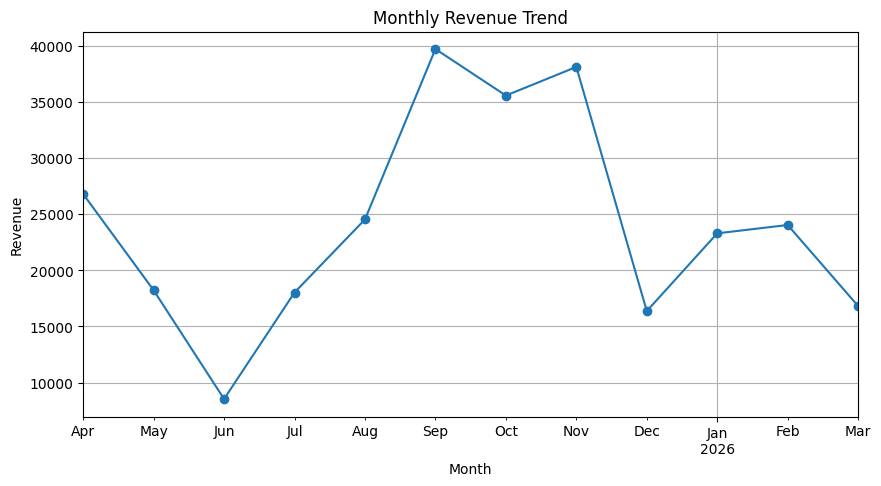

In [5]:
import matplotlib.pyplot as plt

df.set_index('Date', inplace=True)
monthly_sales = df['Revenue'].resample('M').sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(marker='o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)
plt.show()

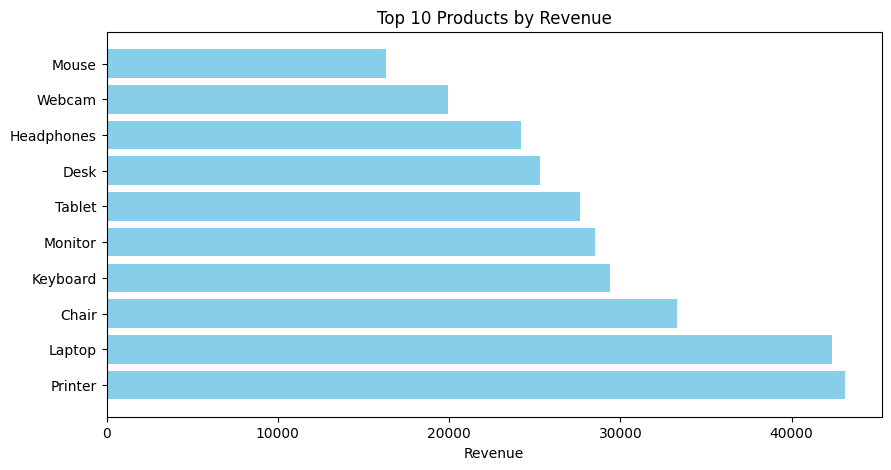

In [6]:
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_products.index, top_products.values, color='skyblue')
plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.show()

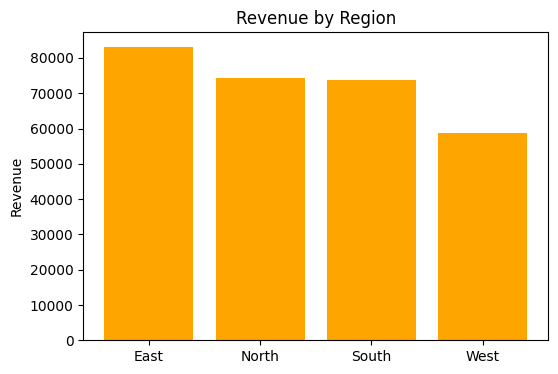

In [7]:
region_sales = df.groupby('Region')['Revenue'].sum()

plt.figure(figsize=(6,4))
plt.bar(region_sales.index, region_sales.values, color='orange')
plt.title("Revenue by Region")
plt.ylabel("Revenue")
plt.show()

Sales Data Analysis – Key Insights
Revenue Overview:
Total revenue: $XX,XXX | Total quantity sold: XXX | Average order: $XXX
Monthly Trend:
Revenue peaks in some months, low in others → seasonal demand.
Top Products:
Laptops, Monitors, and Keyboards generate most revenue.
Low-selling products can be bundled or discounted.
Regional Performance:
North & East regions have higher revenue.
South & West need better marketing or inventory focus.
Correlation:
More quantity sold → higher revenue.
Price sensitivity exists for some products.
